<span style="color:green; font-size:26px; font-weight:bold;">MODELO 3: </span>

<span style="color:green; font-size:33px; font-weight:bold;">LOGISTIC REGRESSION</span>

________________________________________________________________________________________________________________________________


### Justificación   

Tras una primera fase de análisis exploratorio y modelización mediante técnicas de regresión, se observó que la variable objetivo, satisfacción con la vida, presenta una distribución claramente concentrada en los valores altos de la escala (media = 7,31 sobre 10). Aunque la aproximación mediante regresión permitió identificar los factores más relacionados con el bienestar subjetivo y cuantificar su influencia, la interpretación práctica de una predicción numérica exacta resulta limitada desde el punto de vista de la aplicación del modelo.

Por este motivo, se decidió reformular el problema como una tarea de clasificación. El objetivo pasa a ser identificar si una persona presenta o no un nivel elevado de satisfacción con la vida, lo que facilita tanto la interpretación de los resultados como su posible aplicación en contextos reales.

Para ello se construyó una nueva variable binaria denominada "Bienestar_alto", donde los valores de satisfacción entre 0 y 7 se clasifican como 0 (ausencia de bienestar elevado) y los valores entre 8 y 10 como 1 (bienestar elevado). Este punto de corte se seleccionó por varios motivos. En primer lugar, el valor 8 representa un nivel claramente alto de satisfacción dentro de la escala utilizada. En segundo lugar, la distribución resultante genera dos grupos muy equilibrados (aproximadamente 46% frente a 54% de los registros), lo que favorece el entrenamiento y evaluación de modelos de clasificación. Y en tercer lugar, se puede tomar la media (7,31) como punto de corte, entre los más satisfechos y los menos satisfechos con su vida.

Este nuevo enfoque permite abordar una pregunta más relevante desde el punto de vista predictivo: determinar qué características personales, sociales y económicas permiten identificar a las personas con una alta probabilidad de alcanzar elevados niveles de bienestar subjetivo.

Además, el análisis de regresión realizado previamente no pierde utilidad, sino que complementa esta nueva fase del estudio, ya que proporciona evidencia sobre los factores más asociados a la satisfacción vital y sirve como base para la selección de variables utilizadas en los modelos de clasificación.



In [31]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

In [32]:
df_modelo = pd.read_csv("../1_Data/processed.csv", sep = ",")

df_modelo

,Terr_hist,Sexo,Edad_interv,Lugar_nacim,Nacionalidad,Nivel_estudios,Actividad,Tipo_hogar,Target_Satisfacc_Vida,Satisf_relac_pers,Sentido_propia_vida,Satisf_econom_domest,Valor_Estado_animo,Satisf_vivienda,Satisf_tiempo_disp,Satisf_viv_y_entorno,Salud_percibida,Confianza_personas,Confianza_poderes_pub
0,48,6,3,1,1,1,1,3,8,8,9,8,5,9,6,8,3,8,6
1,48,6,6,1,1,1,3,3,9,9,10,9,6,9,10,8,4,8,2
2,48,1,1,1,1,3,1,2,8,8,9,8,8,9,8,9,4,6,3
3,48,1,4,1,1,1,1,1,9,9,9,7,7,10,5,10,4,5,4
4,48,6,6,1,1,3,3,3,8,8,10,8,8,9,10,9,3,7,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5279,1,1,4,1,1,2,1,3,7,9,8,7,8,9,8,8,4,6,6
5280,1,6,7,4,1,1,3,1,6,8,7,3,6,7,10,8,3,5,6
5281,1,6,3,5,1,2,3,2,4,5,5,5,5,8,5,7,3,5,5
5282,1,1,5,4,1,1,1,3,8,8,9,8,8,8,7,8,3,7,5


In [33]:
df_modelo.info()

<class 'pandas.DataFrame'>
RangeIndex: 5284 entries, 0 to 5283
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Terr_hist              5284 non-null   int64
 1   Sexo                   5284 non-null   int64
 2   Edad_interv            5284 non-null   int64
 3   Lugar_nacim            5284 non-null   int64
 4   Nacionalidad           5284 non-null   int64
 5   Nivel_estudios         5284 non-null   int64
 6   Actividad              5284 non-null   int64
 7   Tipo_hogar             5284 non-null   int64
 8   Target_Satisfacc_Vida  5284 non-null   int64
 9   Satisf_relac_pers      5284 non-null   int64
 10  Sentido_propia_vida    5284 non-null   int64
 11  Satisf_econom_domest   5284 non-null   int64
 12  Valor_Estado_animo     5284 non-null   int64
 13  Satisf_vivienda        5284 non-null   int64
 14  Satisf_tiempo_disp     5284 non-null   int64
 15  Satisf_viv_y_entorno   5284 non-null   int64
 16 

In [34]:
df_modelo.describe(include='all')

,Terr_hist,Sexo,Edad_interv,Lugar_nacim,Nacionalidad,Nivel_estudios,Actividad,Tipo_hogar,Target_Satisfacc_Vida,Satisf_relac_pers,Sentido_propia_vida,Satisf_econom_domest,Valor_Estado_animo,Satisf_vivienda,Satisf_tiempo_disp,Satisf_viv_y_entorno,Salud_percibida,Confianza_personas,Confianza_poderes_pub
count,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000
mean,27.478236,3.649508,4.648940,1.975208,1.222369,1.950227,2.026495,2.322104,7.313588,7.793906,7.626041,6.989402,6.411052,7.609765,6.913134,7.322861,2.921840,6.453255,4.495458
std,19.050649,2.495762,1.814499,1.515505,1.030825,0.899861,0.979855,1.240506,1.770229,1.698033,1.803999,1.812392,1.477396,1.832021,2.235819,1.419637,0.767344,1.994762,2.048203
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,20.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000,7.000000,7.000000,6.000000,5.000000,7.000000,6.000000,7.000000,3.000000,5.000000,3.000000
50%,20.000000,6.000000,5.000000,1.000000,1.000000,2.000000,2.000000,2.000000,8.000000,8.000000,8.000000,7.000000,7.000000,8.000000,7.000000,8.000000,3.000000,7.000000,5.000000
75%,48.000000,6.000000,6.000000,4.000000,1.000000,3.000000,3.000000,3.000000,8.000000,9.000000,9.000000,8.000000,7.000000,9.000000,8.000000,8.000000,3.000000,8.000000,6.000000
max,48.000000,6.000000,7.000000,5.000000,6.000000,3.000000,3.000000,5.000000,10.000000,10.000000,10.000000,10.000000,9.000000,10.000000,10.000000,10.000000,4.000000,10.000000,10.000000


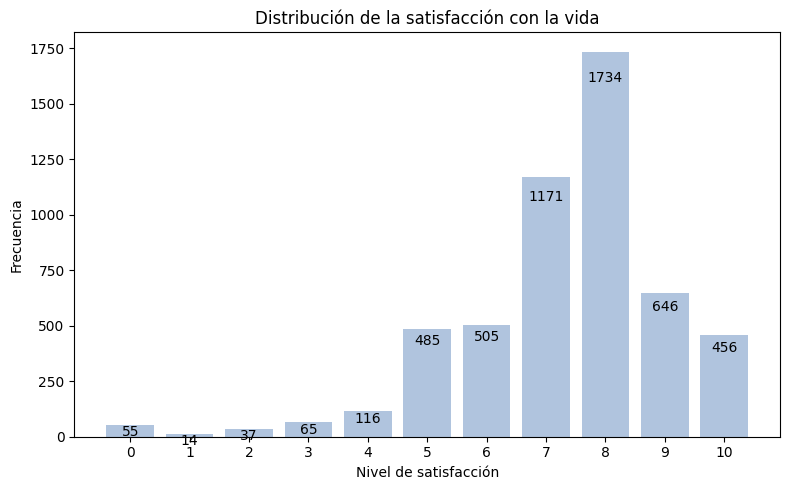

In [35]:
#Saco frecuencias y represento gráficamente la distribución de valores de la target para establecer los dos grupos de clasificación

frecuencias = df_modelo['Target_Satisfacc_Vida'].value_counts().sort_index()

plt.figure(figsize=(8,5))

bars = plt.bar(
    frecuencias.index,
    frecuencias.values,
    color='lightsteelblue'
)

# Etiquetas dentro de las barras
for bar in bars:
    altura = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura*0.95,
        f'{int(altura)}',
        ha='center',
        va='top'
    )

plt.title('Distribución de la satisfacción con la vida')
plt.xlabel('Nivel de satisfacción')
plt.ylabel('Frecuencia')

plt.xticks(frecuencias.index)

plt.tight_layout()
plt.show()

In [36]:
tabla_target = pd.DataFrame({
    'Frecuencia': df_modelo['Target_Satisfacc_Vida'].value_counts().sort_index()
})

tabla_target['Porcentaje'] = (
    tabla_target['Frecuencia'] /
    tabla_target['Frecuencia'].sum() * 100
).round(2)

tabla_target

,Frecuencia,Porcentaje
Target_Satisfacc_Vida,,
0,55,1.04
1,14,0.26
2,37,0.70
3,65,1.23
4,116,2.20
5,485,9.18
6,505,9.56
7,1171,22.16
8,1734,32.82


In [37]:
media_target = df_modelo['Target_Satisfacc_Vida'].mean()
media_target

np.float64(7.313588190764572)

In [38]:
df_modelo['Bienestar_alto'] = (
    df_modelo['Target_Satisfacc_Vida'] >= 8
).astype(int)

In [39]:
tabla_clases = pd.DataFrame({
    'Frecuencia': df_modelo['Bienestar_alto'].value_counts().sort_index()
})

tabla_clases['Porcentaje'] = (
    tabla_clases['Frecuencia'] /
    tabla_clases['Frecuencia'].sum() * 100
).round(2)

tabla_clases.index = [
    'No bienestar alto (0-7)',
    'Bienestar alto (8-10)'
]

tabla_clases

,Frecuencia,Porcentaje
No bienestar alto (0-7),2448,46.33
Bienestar alto (8-10),2836,53.67


In [41]:
# Guardo el dataframe final para modelado
df_modelo.to_csv('processed_clas.csv', index=False, encoding='utf-8')
df_modelo.head()

,Terr_hist,Sexo,Edad_interv,Lugar_nacim,Nacionalidad,Nivel_estudios,Actividad,Tipo_hogar,Target_Satisfacc_Vida,Satisf_relac_pers,Sentido_propia_vida,Satisf_econom_domest,Valor_Estado_animo,Satisf_vivienda,Satisf_tiempo_disp,Satisf_viv_y_entorno,Salud_percibida,Confianza_personas,Confianza_poderes_pub,Bienestar_alto
0,48,6,3,1,1,1,1,3,8,8,9,8,5,9,6,8,3,8,6,1
1,48,6,6,1,1,1,3,3,9,9,10,9,6,9,10,8,4,8,2,1
2,48,1,1,1,1,3,1,2,8,8,9,8,8,9,8,9,4,6,3,1
3,48,1,4,1,1,1,1,1,9,9,9,7,7,10,5,10,4,5,4,1
4,48,6,6,1,1,3,3,3,8,8,10,8,8,9,10,9,3,7,5,1


Con el objetivo de homogeneizar la escala de las variables predictoras, aplico una estandarización mediante StandardScaler. Esta transformación centra cada variable en media cero y desviación típica uno. El escalador se ajusta exclusivamente sobre el conjunto de entrenamiento y posteriormente se aplica al conjunto de prueba.